## Importing Modules and Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
import astropy.units as u
import urllib.request
import os
import gzip
import shutil
from astropy.io import fits

## Downloading FITS File for M101 

In [4]:
from astropy.utils.data import download_file

m101_url = "https://mast.stsci.edu/api/v0.1/Download/file/?uri=mast:JWST/product/jw03429-o004_t002_nircam_clear-f335m_i2d.fits"
image_file = download_file(m101_url, cache = True)
image_file 
#"https://opencomputinglab.github.io/SubjectMatterNotebooks/astronomy/fits-images.html"

'C:\\Users\\mya\\.astropy\\cache\\download\\url\\54091ca7014394562d075c292f47cabf\\contents'

## Opening FITS and Reading Header for M101

In [5]:
hdu_list = fits.open(image_file)
if 'm101.fits' not in os.listdir():
    hdu_list.writeto('m101.fits')


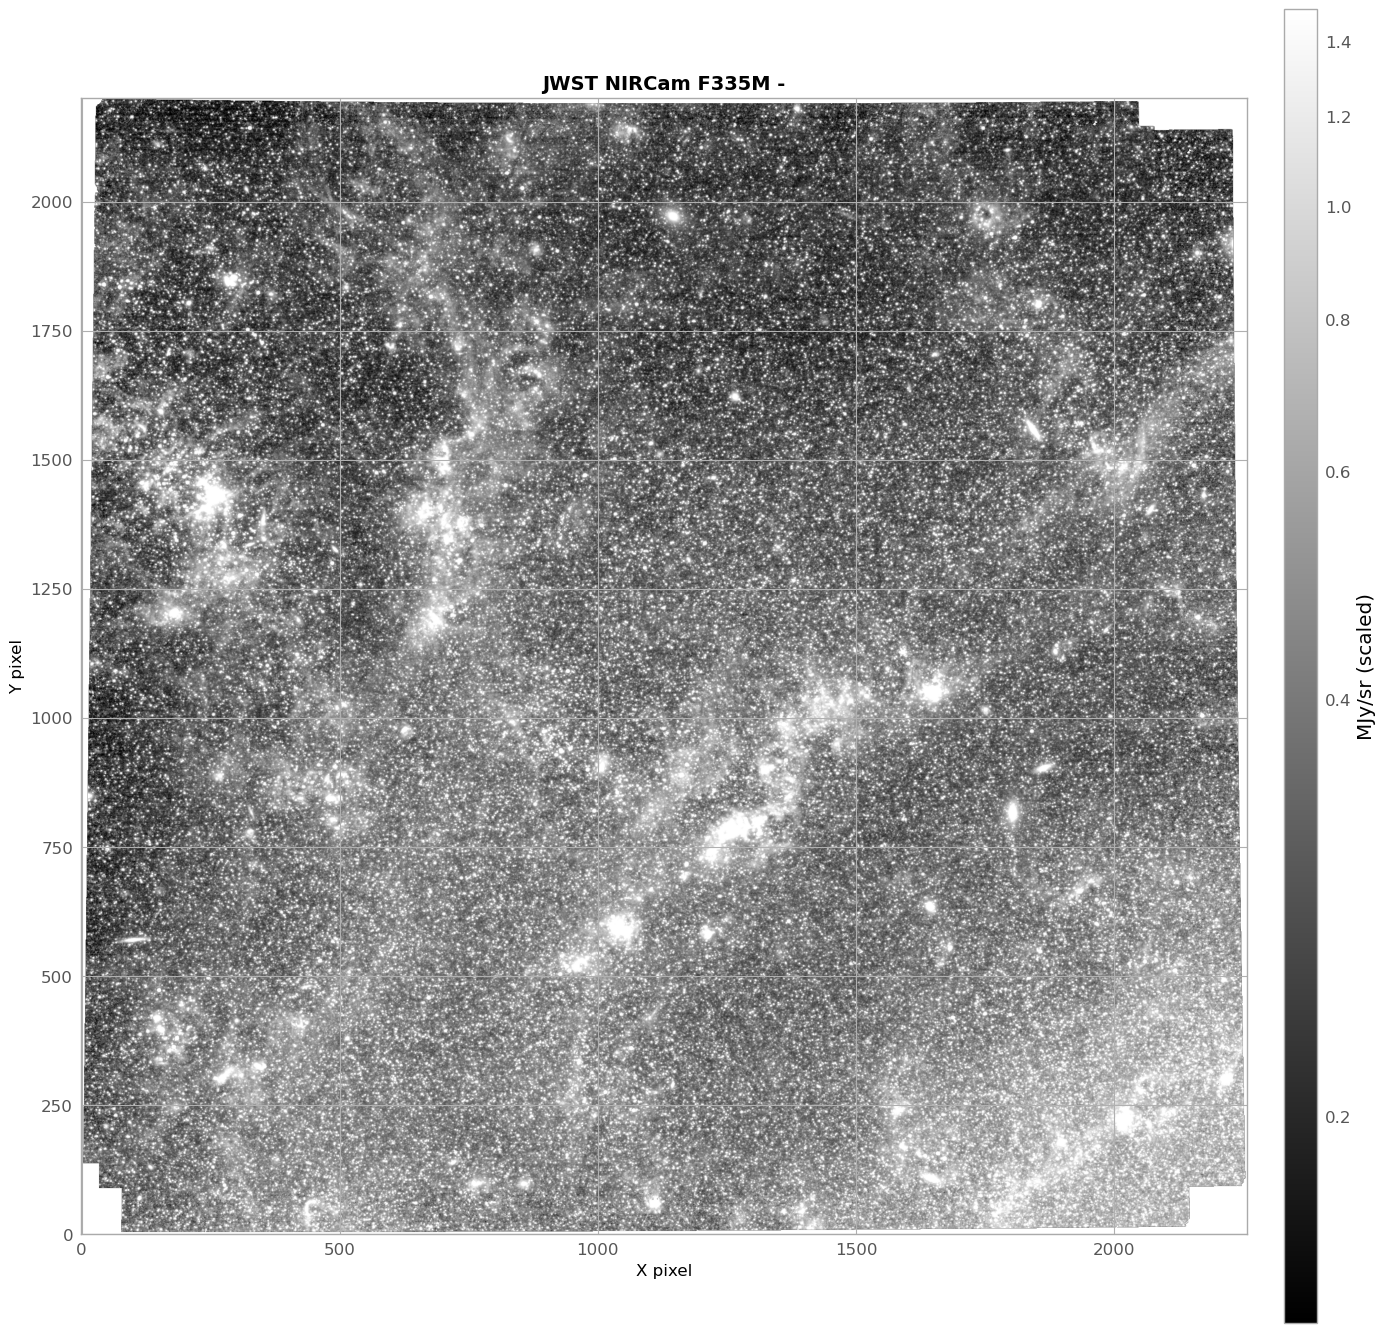

In [20]:

#Nice styling
from astropy.visualization import astropy_mpl_style
plt.style.use(astropy_mpl_style)

image_data = fits.getdata('m101.fits')

#Display the image
#plt.imshow(image_data, cmap='gray')
#plt.colorbar();
#Lecture 14
if os.path.exists(image_file) and image_data is not None:
    from astropy.visualization import ZScaleInterval, AsinhStretch, ImageNormalize
    
    # Combine interval (ZScale finds optimal min/max) with stretch (AsinhStretch compresses dynamic range)
    norm = ImageNormalize(image_data, 
                          interval=ZScaleInterval(),
                          stretch=AsinhStretch())
    
    # Calculate figure size maintaining aspect ratio
    aspect_ratio = image_data.shape[0] / image_data.shape[1]
    fig_width = 14
    fig_height = fig_width * aspect_ratio
    
    plt.figure(figsize=(fig_width, fig_height))
    
    # origin='lower' puts (0,0) at bottom-left (astronomical convention)
    plt.imshow(image_data, cmap='gray', origin='lower', norm=norm)
    plt.colorbar(label='MJy/sr (scaled)', fraction=0.03, pad=0.03, aspect=40)
    plt.title('JWST NIRCam F335M - M101 "Pinwheel Galaxy', 
              fontsize=14, fontweight='bold')
    plt.xlabel('X pixel', fontsize=12)
    plt.ylabel('Y pixel', fontsize=12)
    plt.tight_layout()
    plt.show()
elif os.path.exists(image_file):
    print("Skipping visualization - no image data loaded")

## Creating DataFrame for M101

In [7]:

if os.path.exists(image_file):
    hdulist = fits.open(image_file)
    print(f"FITS file structure:")
    print(f"="*60)
    hdulist.info()
    print(f"="*60)
    print(f"\nThe file contains {len(hdulist)} HDUs (Header-Data Units)")
else:
    print(f"File {image_file} not found.")

FITS file structure:
Filename: C:\Users\mya\.astropy\cache\download\url\54091ca7014394562d075c292f47cabf\contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     275   ()      
  1  SCI           1 ImageHDU        75   (2257, 2201)   float32   
  2  ERR           1 ImageHDU        10   (2257, 2201)   float32   
  3  CON           1 ImageHDU        10   (2257, 2201, 1)   int32   
  4  WHT           1 ImageHDU         9   (2257, 2201)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (2257, 2201)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (2257, 2201)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (2257, 2201)   float32   
  8  HDRTAB        1 BinTableHDU    526   4R x 258C   [23A, 5A, 3A, 48A, 7A, 13A, 3A, 5A, 6A, 7A, 10A, 4A, L, D, D, 32A, 50A, 59A, 18A, 2A, 47A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 12A, 12A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 12A, 7A, 5A, D, D, D, D, D, D, D, D, 6A,

In [19]:
if os.path.exists(image_file):
    # Extract primary HDU (Header Data Unit)
    primary = hdulist[0]
    header = primary.header
    
    # Read key metadata from header using .get() for safe access
obs_info = {
    
    "Telescope":   [{header.get('TELESCOP', 'N/A')}],
    "Instrument":  [{header.get('INSTRUME', 'N/A')}],
    "Filter":      [{header.get('FILTER', 'N/A')}],
    "Observation date": [{header.get('DATE-OBS', 'N/A')}],
    "Data units":       [{header.get('BUNIT', 'N/A')}],
    "Target field":     [{header.get('TARGPROP', 'EGS Field')}],
}
#Lecture 11
obs_df = pd.DataFrame(
    obs_info,  # Dictionary where keys become column names
    index=["M101"]  # Row labels
)
print("DataFrame with star names as index:")
print(obs_df)
print(f"\nDataFrame shape: {obs_df.shape} (rows, columns)")


  

DataFrame with star names as index:
     Telescope Instrument   Filter Observation date Data units    Target field
M101    {JWST}   {NIRCAM}  {F335M}     {2024-06-11}      {N/A}  {M101-NGC5462}

DataFrame shape: (1, 6) (rows, columns)
